# 02 — Modeling Results, Model Comparison, Error Analysis, and Final Interpretation

## Why this notebook matters

This notebook consolidates the final evaluation stage of the project.  
Its purpose is to compare baseline and machine learning approaches under a **time-aware evaluation setup**, explain the methodological choices behind the experiments, and justify the final model selection with clear evidence.

The notebook covers:
- baseline performance,
- Random Forest comparison across feature blocks,
- hyperparameter tuning with time-aware cross-validation,
- an additional benchmark with HistGradientBoostingRegressor,
- permutation importance,
- residual and geographic error analysis,
- and final model selection.


## 1. Load model outputs

The notebook loads the artifacts produced by the training scripts:
- baseline metrics,
- Random Forest results and predictions,
- HistGradientBoosting results and predictions,
- permutation importance tables,
- and the engineered feature dataset used for auxiliary diagnostics.

All datasets are sorted before analysis so that comparisons remain consistent and reproducible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")

baseline_results = pd.read_csv("../reports/baseline_metrics.csv")
rf_results = pd.read_csv("../reports/ml_results.csv")
rf_importance_df = pd.read_csv("../reports/ml_feature_importance.csv")
rf_predictions = pd.read_parquet("../reports/ml_predictions.parquet")

hgb_results = pd.read_csv("../reports/hgb_results.csv")
hgb_importance_df = pd.read_csv("../reports/hgb_feature_importance.csv")
hgb_predictions = pd.read_parquet("../reports/hgb_predictions.parquet")

feature_df = pd.read_parquet("../data/processed/GlobalWeatherRepository_features.parquet")

baseline_results = baseline_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
rf_results = rf_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
rf_importance_df = rf_importance_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)

hgb_results = hgb_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
hgb_importance_df = hgb_importance_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)

baseline_results.head(), rf_results.head(), hgb_results.head()

(              model       mae      rmse        r2       mape
 0  last_observation  1.851315  2.725922  0.940315  55.886455
 1    rolling_mean_3  2.153061  3.120490  0.921786  69.991565
 2       naive_lag_1  2.297220  3.362395  0.909189  72.557792
 3       naive_lag_2  2.475494  3.602066  0.895782  80.603152
 4       naive_lag_3  2.548230  3.702112  0.889913  80.783772,
                         feature_set  n_features                        model  \
 0  C_temporal_meteorology_geography          29  RandomForestRegressor_tuned   
 1  C_temporal_meteorology_geography          29        RandomForestRegressor   
 2            B_temporal_meteorology          27        RandomForestRegressor   
 3                            D_full          37        RandomForestRegressor   
 4                   A_temporal_core          18        RandomForestRegressor   
 
         mae      rmse        r2       mape  \
 0  1.743873  2.528803  0.948608  56.549117   
 1  1.754461  2.553303  0.947607  55.453987  

## 2. Evaluation design and methodological choices

### Why an 80/20 temporal split?
A chronological **80/20 holdout split** was used so the models were always trained on earlier observations and evaluated on later ones.  
This design is appropriate for forecasting because it avoids leakage from future records into the training process while still preserving a large historical window for learning.

### Why compare baselines first?
The baseline stage establishes a serious minimum performance threshold.  
In short-term weather forecasting, persistence-based strategies can already be strong because temperature usually has high short-term autocorrelation.  
A machine learning model should therefore be judged against a strong baseline, not against a trivial benchmark.

### Why RandomizedSearchCV instead of exhaustive grid search?
`RandomizedSearchCV` was used to explore the hyperparameter space more efficiently than a full Cartesian grid.  
This is a pragmatic choice for tabular forecasting experiments because it reduces computational cost while still allowing competitive parameter search over meaningful ranges.

### Why TimeSeriesSplit during tuning?
Hyperparameter tuning used `TimeSeriesSplit(n_splits=3)` so that each validation fold preserved temporal ordering.  
This is more appropriate than a standard shuffled or generic K-fold approach for time-dependent data because the validation process should respect the forecasting structure of the problem.


In [95]:
rf_results[rf_results["model"] == "RandomForestRegressor_tuned"]

,feature_set,n_features,model,mae,rmse,r2,mape,best_params
0,C_temporal_meteorology_geography,29,RandomForestRegressor_tuned,1.743873,2.528803,0.948608,56.549117,"{'model__n_estimators': 250, 'model__min_sampl..."


## 3. Executive summary table

In [96]:
best_baseline = baseline_results.iloc[0].copy()

best_untuned_rf = (
    rf_results[rf_results["model"] == "RandomForestRegressor"]
    .sort_values(["mae", "rmse"])
    .iloc[0]
    .copy()
)

best_tuned_rf = (
    rf_results[rf_results["model"] == "RandomForestRegressor_tuned"]
    .sort_values(["mae", "rmse"])
    .iloc[0]
    .copy()
)

best_untuned_hgb = (
    hgb_results[hgb_results["model"] == "HistGradientBoostingRegressor"]
    .sort_values(["mae", "rmse"])
    .iloc[0]
    .copy()
)

best_tuned_hgb = (
    hgb_results[hgb_results["model"] == "HistGradientBoostingRegressor_tuned"]
    .sort_values(["mae", "rmse"])
    .iloc[0]
    .copy()
)

summary_df = pd.DataFrame([
    {
        "approach": "Best baseline",
        "configuration": best_baseline["model"],
        "feature_set": "-",
        "mae": best_baseline["mae"],
        "rmse": best_baseline["rmse"],
        "r2": best_baseline["r2"],
        "mape": best_baseline["mape"],
    },
    {
        "approach": "Best Random Forest (tuned)",
        "configuration": best_tuned_rf["model"],
        "feature_set": best_tuned_rf["feature_set"],
        "mae": best_tuned_rf["mae"],
        "rmse": best_tuned_rf["rmse"],
        "r2": best_tuned_rf["r2"],
        "mape": best_tuned_rf["mape"],
    },
    {
        "approach": "Best HistGradientBoosting (tuned)",
        "configuration": best_tuned_hgb["model"],
        "feature_set": best_tuned_hgb["feature_set"],
        "mae": best_tuned_hgb["mae"],
        "rmse": best_tuned_hgb["rmse"],
        "r2": best_tuned_hgb["r2"],
        "mape": best_tuned_hgb["mape"],
    },
]).sort_values(["mae", "rmse"]).reset_index(drop=True)

summary_df

,approach,configuration,mae,rmse,r2,mape
0,Best baseline,last_observation,1.851315,2.725922,0.940315,55.886455
1,Best ML (untuned),RandomForestRegressor | C_temporal_meteorology...,1.754461,2.553303,0.947607,55.453987
2,Best ML (tuned),RandomForestRegressor_tuned | C_temporal_meteo...,1.743873,2.528803,0.948608,56.549117


In [97]:
mae_gain_abs = best_baseline["mae"] - best_tuned_rf["mae"]
mae_gain_pct = mae_gain_abs / best_baseline["mae"] * 100
rmse_gain_abs = best_baseline["rmse"] - best_tuned_rf["rmse"]
r2_gain_abs = best_tuned_rf["r2"] - best_baseline["r2"]

rf_vs_hgb_mae_gap = best_tuned_hgb["mae"] - best_tuned_rf["mae"]
rf_vs_hgb_rmse_gap = best_tuned_hgb["rmse"] - best_tuned_rf["rmse"]

summary_text = f'''
### Initial finding

The strongest baseline was **{best_baseline["model"]}** with **MAE = {best_baseline["mae"]:.3f}** and **R² = {best_baseline["r2"]:.3f}**.  
The best final model was the tuned **Random Forest** using **{best_tuned_rf["feature_set"]}**, reaching **MAE = {best_tuned_rf["mae"]:.3f}**, **RMSE = {best_tuned_rf["rmse"]:.3f}**, and **R² = {best_tuned_rf["r2"]:.3f}**.

Relative to the strongest baseline, the final Random Forest improved MAE by **{mae_gain_abs:.3f} °C** (**{mae_gain_pct:.2f}%**) and improved RMSE by **{rmse_gain_abs:.3f} °C**.  
An additional tuned **HistGradientBoosting** benchmark remained competitive, but its MAE was **{rf_vs_hgb_mae_gap:.3f} °C** higher and its RMSE was **{rf_vs_hgb_rmse_gap:.3f} °C** higher than the tuned Random Forest.
'''
display(Markdown(summary_text))


### Initial finding

The strongest baseline was **last_observation** with **MAE = 1.851** and **R² = 0.940**.  
The best final model was **RandomForestRegressor_tuned** using **C_temporal_meteorology_geography**, reaching **MAE = 1.744**, **RMSE = 2.529**, and **R² = 0.949**.  

Relative to the strongest baseline, the tuned model improved MAE by **0.107 °C** (**5.80%**) and improved RMSE by **0.197 °C**.  
This indicates that the machine learning pipeline added predictive value beyond simple persistence.


## 4. Baseline performance

In [98]:
baseline_results

,model,mae,rmse,r2,mape
0,last_observation,1.851315,2.725922,0.940315,55.886455
1,rolling_mean_3,2.153061,3.120490,0.921786,69.991565
2,naive_lag_1,2.297220,3.362395,0.909189,72.557792
3,naive_lag_2,2.475494,3.602066,0.895782,80.603152
4,naive_lag_3,2.548230,3.702112,0.889913,80.783772


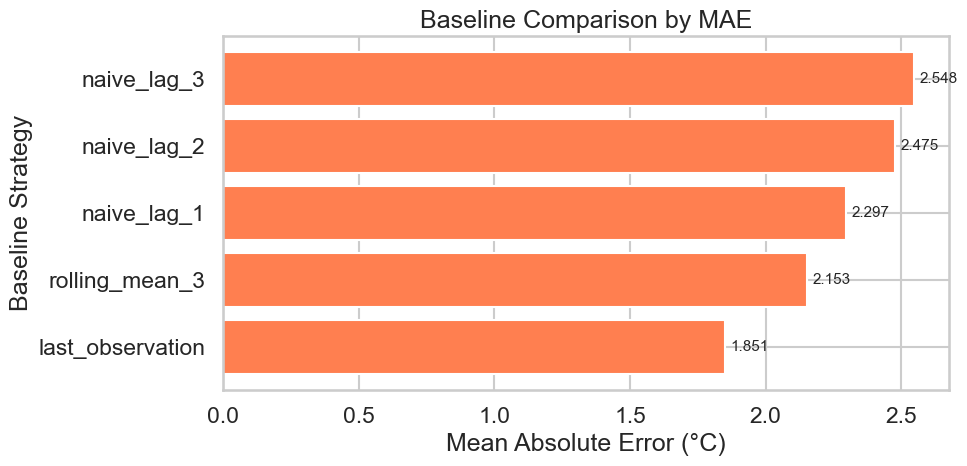

In [99]:
fig, ax = plt.subplots(figsize=(10, 5))
baseline_plot = baseline_results.sort_values("mae", ascending=True)

ax.barh(baseline_plot["model"], baseline_plot["mae"], color="coral")
ax.set_title("Baseline Comparison by MAE")
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("Baseline Strategy")

for i, v in enumerate(baseline_plot["mae"]):
    ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

### Interpretation

The baseline section establishes the minimum performance threshold that a more complex model must beat to justify its added complexity.  
Here, the `last_observation` baseline is notably stronger than the lag-only alternatives, which suggests strong short-term persistence in the temperature series.

## 5. Random Forest comparison across feature blocks

The first supervised benchmark used **RandomForestRegressor**.  
This choice was motivated by three properties that fit the project well:
- robustness on mixed tabular features,
- ability to capture nonlinear interactions without heavy preprocessing,
- and compatibility with permutation-based interpretation.

The model was first evaluated across structured feature blocks before any tuning step.  
This makes it possible to separate the effect of **feature design** from the effect of **hyperparameter optimization**.


In [100]:
rf_results

,feature_set,n_features,model,mae,rmse,r2,mape,best_params
0,C_temporal_meteorology_geography,29,RandomForestRegressor_tuned,1.743873,2.528803,0.948608,56.549117,"{'model__n_estimators': 250, 'model__min_sampl..."
1,C_temporal_meteorology_geography,29,RandomForestRegressor,1.754461,2.553303,0.947607,55.453987,NaN
2,B_temporal_meteorology,27,RandomForestRegressor,1.757000,2.566012,0.947085,55.289049,NaN
3,D_full,37,RandomForestRegressor,1.759364,2.569779,0.946929,55.047383,NaN
4,A_temporal_core,18,RandomForestRegressor,1.799388,2.633394,0.944269,54.870132,NaN


## Model comparison

This section compares the machine learning configurations using MAE and RMSE.  
The objective is to determine whether adding meteorological, geographic, and environmental predictors improves performance beyond the temporal core, and whether hyperparameter tuning provides additional value.

In [101]:
comparison_plot = rf_results.copy()

label_map = {
    "A_temporal_core": "A | Temporal core",
    "B_temporal_meteorology": "B | Temporal + meteorology",
    "C_temporal_meteorology_geography": "C | Temporal + meteorology + geography",
    "D_full": "D | Full feature set",
}

comparison_plot["feature_label"] = comparison_plot["feature_set"].map(label_map)
comparison_plot["model_label"] = comparison_plot["model"].replace(
    {
        "RandomForestRegressor": "Random Forest",
        "RandomForestRegressor_tuned": "Random Forest (tuned)",
    }
)

comparison_plot["label"] = comparison_plot["feature_label"] + " | " + comparison_plot["model_label"]
comparison_plot

,feature_set,n_features,model,mae,rmse,r2,mape,best_params,feature_label,model_label,label
0,C_temporal_meteorology_geography,29,RandomForestRegressor_tuned,1.743873,2.528803,0.948608,56.549117,"{'model__n_estimators': 250, 'model__min_sampl...",C | Temporal + meteorology + geography,Random Forest (tuned),C | Temporal + meteorology + geography | Rando...
1,C_temporal_meteorology_geography,29,RandomForestRegressor,1.754461,2.553303,0.947607,55.453987,NaN,C | Temporal + meteorology + geography,Random Forest,C | Temporal + meteorology + geography | Rando...
2,B_temporal_meteorology,27,RandomForestRegressor,1.757000,2.566012,0.947085,55.289049,NaN,B | Temporal + meteorology,Random Forest,B | Temporal + meteorology | Random Forest
3,D_full,37,RandomForestRegressor,1.759364,2.569779,0.946929,55.047383,NaN,D | Full feature set,Random Forest,D | Full feature set | Random Forest
4,A_temporal_core,18,RandomForestRegressor,1.799388,2.633394,0.944269,54.870132,NaN,A | Temporal core,Random Forest,A | Temporal core | Random Forest


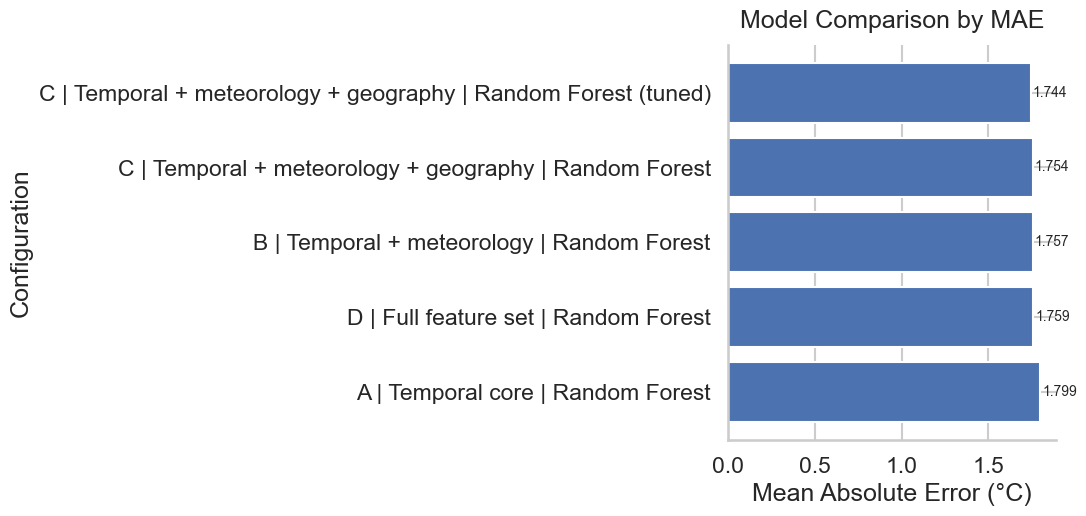

In [102]:
plot_mae = comparison_plot.sort_values("mae", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(plot_mae["label"], plot_mae["mae"])

ax.set_title("Model Comparison by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("Configuration")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

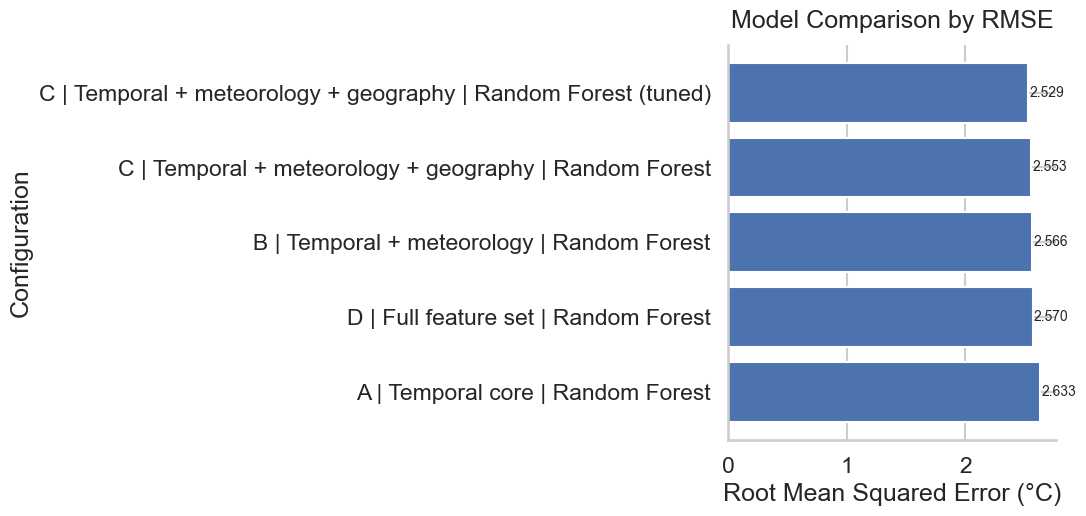

In [103]:
plot_rmse = comparison_plot.sort_values("rmse", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(plot_rmse["label"], plot_rmse["rmse"])

ax.set_title("Model Comparison by RMSE", pad=12)
ax.set_xlabel("Root Mean Squared Error (°C)")
ax.set_ylabel("Configuration")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [104]:
best_baseline = baseline_results.sort_values("mae", ascending=True).iloc[0].copy()
best_rf = rf_results.sort_values("mae", ascending=True).iloc[0].copy()

rf_vs_baseline_df = pd.DataFrame(
    [
        {
            "configuration": "Best baseline",
            "mae": best_baseline["mae"],
            "rmse": best_baseline["rmse"],
            "r2": best_baseline["r2"],
        },
        {
            "configuration": "Best Random Forest",
            "mae": best_rf["mae"],
            "rmse": best_rf["rmse"],
            "r2": best_rf["r2"],
        },
    ]
)

rf_vs_baseline_df

,configuration,mae,rmse,r2
0,Best baseline,1.851315,2.725922,0.940315
1,Best ML model,1.743873,2.528803,0.948608


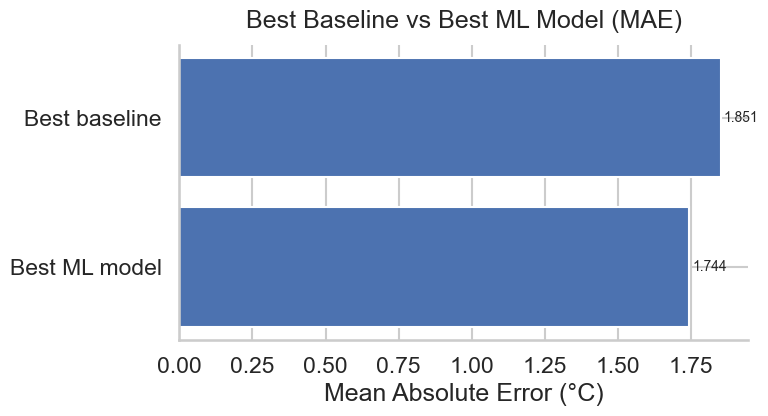

In [105]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(rf_vs_baseline_df["configuration"], rf_vs_baseline_df["mae"])

ax.set_title("Best Baseline vs Best Random Forest (MAE)", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [106]:
feature_block_results = (
    rf_results[rf_results["model"] == "RandomForestRegressor"]
    .sort_values("mae")
    .reset_index(drop=True)
)

block_summary = f'''
### Initial finding

Among the untuned Random Forest feature blocks, **{feature_block_results.iloc[0]["feature_set"]}** achieved the best performance with **MAE = {feature_block_results.iloc[0]["mae"]:.3f}**.  
This indicates that adding **meteorological** and **geographic** context improved performance relative to the temporal-only block, while the **full** configuration with air-quality variables did not outperform the best intermediate setup.
'''
display(Markdown(block_summary))


### Initial finding

Among the untuned feature blocks, **C_temporal_meteorology_geography** achieved the best performance with **MAE = 1.754**.  
The ranking suggests that adding **meteorological** and **geographic** context improved performance relative to the temporal-only block, while the **full** configuration with air-quality variables did not outperform the best intermediate setup.


## 6. Permutation importance of the best tuned Random Forest model

In [107]:
top_importance = rf_importance_df.head(15).copy()
top_importance

,feature,importance_mean,importance_std,feature_set
0,temperature_celsius,3.836215,0.014983,C_temporal_meteorology_geography
1,feels_like_celsius,2.855105,0.022283,C_temporal_meteorology_geography
2,temp_roll_mean_3,0.514289,0.007060,C_temporal_meteorology_geography
3,temp_lag_3,0.074038,0.002052,C_temporal_meteorology_geography
4,latitude,0.062531,0.002296,C_temporal_meteorology_geography
5,temp_lag_1,0.037366,0.001722,C_temporal_meteorology_geography
6,temp_lag_2,0.036211,0.001528,C_temporal_meteorology_geography
7,pressure_mb,0.025009,0.001399,C_temporal_meteorology_geography
8,humidity,0.012265,0.000720,C_temporal_meteorology_geography
9,uv_index,0.004964,0.000521,C_temporal_meteorology_geography


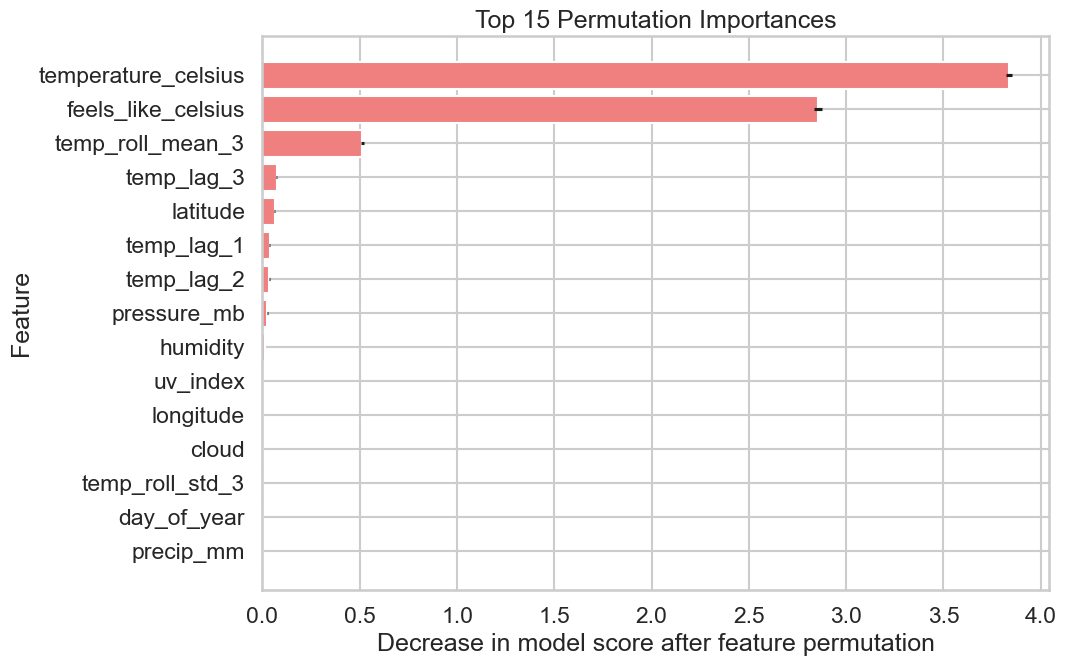

In [108]:
top_importance_plot = top_importance.sort_values("importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    top_importance_plot["feature"],
    top_importance_plot["importance_mean"],
    xerr=top_importance_plot["importance_std"],
    color="lightcoral",
)
ax.set_title("Top 15 Permutation Importances")
ax.set_xlabel("Decrease in model score after feature permutation")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

In [109]:
top3 = rf_importance_df.head(3)["feature"].tolist()

display(Markdown(f"### Initial finding\n\nThe top three variables by permutation importance were **{top3[0]}**, **{top3[1]}**, and **{top3[2]}**. This supports the earlier correlation analysis, which suggested that recent thermal history and closely related meteorological context dominate short-term forecasting performance."))


### Initial finding

The importance analysis shows a clear hierarchy. The top contributors were **temperature_celsius**, **feels_like_celsius**, and **temp_roll_mean_3**.  
This supports the earlier correlation analysis: short-term prediction is driven mainly by recent thermal information, with additional gains from contextual variables rather than from the full environmental block.


## 7. Additional benchmark: HistGradientBoostingRegressor

To strengthen model selection, a second tabular ensemble family was evaluated under the **same 80/20 temporal holdout** and the **same `TimeSeriesSplit(n_splits=3)` tuning protocol** used for Random Forest.  
`HistGradientBoostingRegressor` was chosen as a strong boosting-based benchmark because it is efficient on tabular data and provides a meaningful contrast against the bagging-based Random Forest approach.

This section checks whether gradient boosting can outperform the final Random Forest configuration under a comparable experimental design.


In [ ]:
hgb_results

In [ ]:
best_hgb_feature_blocks = (
    hgb_results[hgb_results["model"] == "HistGradientBoostingRegressor"]
    .sort_values("mae")
    .reset_index(drop=True)
)

display(best_hgb_feature_blocks)

In [ ]:
final_model_selection_df = pd.DataFrame(
    [
        {
            "model_family": "Baseline",
            "configuration": best_baseline["model"],
            "feature_set": "-",
            "mae": best_baseline["mae"],
            "rmse": best_baseline["rmse"],
            "r2": best_baseline["r2"],
        },
        {
            "model_family": "Random Forest",
            "configuration": best_tuned_rf["model"],
            "feature_set": best_tuned_rf["feature_set"],
            "mae": best_tuned_rf["mae"],
            "rmse": best_tuned_rf["rmse"],
            "r2": best_tuned_rf["r2"],
        },
        {
            "model_family": "HistGradientBoosting",
            "configuration": best_tuned_hgb["model"],
            "feature_set": best_tuned_hgb["feature_set"],
            "mae": best_tuned_hgb["mae"],
            "rmse": best_tuned_hgb["rmse"],
            "r2": best_tuned_hgb["r2"],
        },
    ]
).sort_values(["mae", "rmse"]).reset_index(drop=True)

final_model_selection_df

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.barh(final_model_selection_df["model_family"], final_model_selection_df["mae"])

ax.set_title("Final Model Selection by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

The **tuned Random Forest** remained the best-performing final model.  
Although **HistGradientBoostingRegressor** stayed competitive, it did not surpass the Random Forest on MAE, RMSE, or R². This supports the final selection of the tuned Random Forest as the primary model for the project.

A useful by-product of this comparison is methodological confidence: the final model was not chosen arbitrarily, but selected after comparing **baseline persistence**, **bagging-based ensembles**, and **boosting-based ensembles** under the same temporal evaluation logic.


## 8. Prediction error analysis for the selected final model

The final error analysis is performed on the **selected production candidate**, which is the tuned Random Forest model.  
This choice follows the model-comparison evidence shown above: it outperformed both the strongest baseline and the tuned HistGradientBoosting benchmark on the temporal holdout set.


In [110]:
best_feature_set = best_tuned_rf["feature_set"]
best_preds = rf_predictions[rf_predictions["feature_set"] == best_feature_set].copy()

best_preds["error"] = best_preds["target_temperature_next"] - best_preds["prediction"]
best_preds["absolute_error"] = best_preds["error"].abs()

best_preds.head()

,location_name,country,last_updated,target_temperature_next,feature_set,prediction,error,absolute_error
52134,Madrid,Spain,2025-11-04 08:45:00,12.3,C_temporal_meteorology_geography,9.021127,3.278873,3.278873
52135,Warsaw,Poland,2025-11-04 09:00:00,6.1,C_temporal_meteorology_geography,8.048903,-1.948903,1.948903
52136,'S-Gravenbrakel,Belgium,2025-11-04 09:00:00,12.3,C_temporal_meteorology_geography,10.653892,1.646108,1.646108
52137,Andorra La Vella,Andorra,2025-11-04 09:00:00,5.5,C_temporal_meteorology_geography,6.791142,-1.291142,1.291142
52138,Amsterdam,Netherlands,2025-11-04 09:00:00,12.3,C_temporal_meteorology_geography,11.174860,1.125140,1.125140


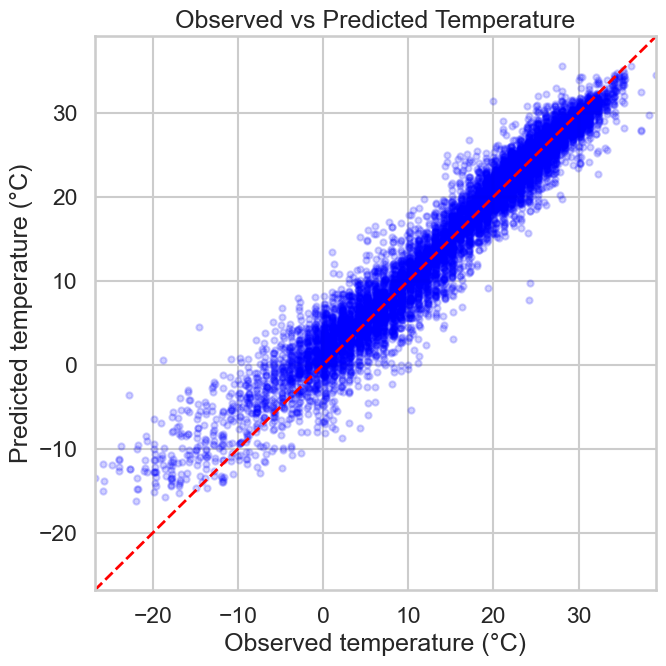

In [111]:
sample_n = min(len(best_preds), 12000)
plot_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

obs_min = min(plot_sample["target_temperature_next"].min(), plot_sample["prediction"].min())
obs_max = max(plot_sample["target_temperature_next"].max(), plot_sample["prediction"].max())

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_sample["target_temperature_next"], plot_sample["prediction"], c="blue", alpha=0.18, s=20)
ax.plot([obs_min, obs_max], [obs_min, obs_max], linestyle="--", c="red", linewidth=2)
ax.set_title("Observed vs Predicted Temperature")
ax.set_xlabel("Observed temperature (°C)")
ax.set_ylabel("Predicted temperature (°C)")
ax.set_xlim(obs_min, obs_max)
ax.set_ylim(obs_min, obs_max)
plt.tight_layout()
plt.show()

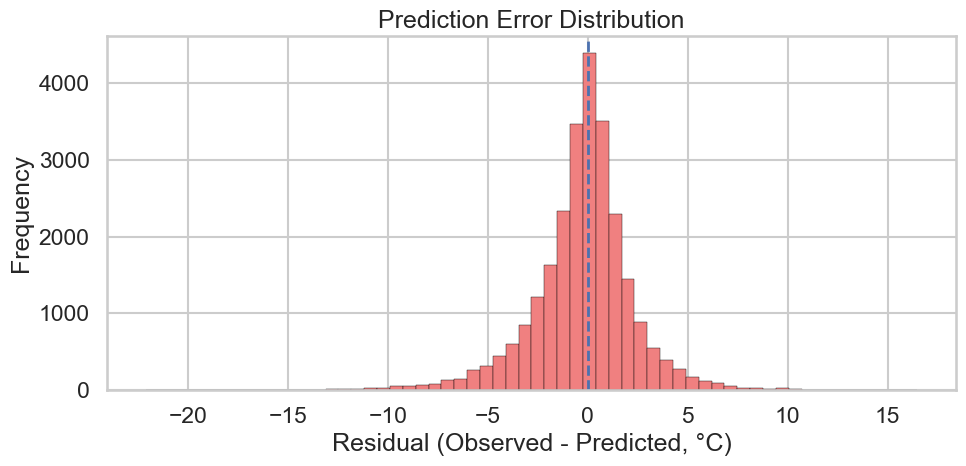

In [112]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_preds["error"], bins=60, edgecolor="black", color="lightcoral",linewidth=0.3)
ax.axvline(0, linestyle="--", linewidth=2)
ax.set_title("Prediction Error Distribution")
ax.set_xlabel("Residual (Observed - Predicted, °C)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

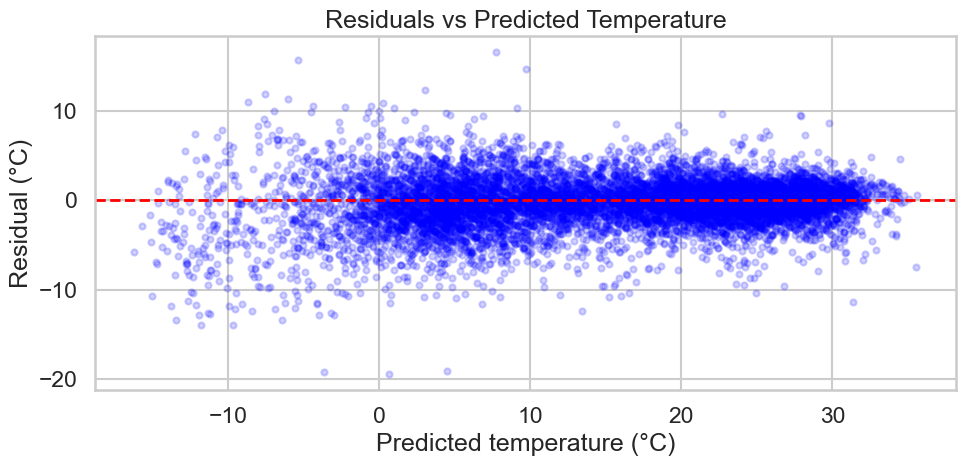

In [113]:
sample_n = min(len(best_preds), 12000)
resid_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(resid_sample["prediction"], resid_sample["error"], c="blue", alpha=0.18, s=20)
ax.axhline(0, linestyle="--", c="red", linewidth=2)
ax.set_title("Residuals vs Predicted Temperature")
ax.set_xlabel("Predicted temperature (°C)")
ax.set_ylabel("Residual (°C)")
plt.tight_layout()
plt.show()

In [114]:
best_preds["absolute_error"] = best_preds["error"].abs()

error_summary = (
    best_preds["absolute_error"]
    .describe(percentiles=[0.5, 0.9, 0.95])
    [["mean", "50%", "90%", "95%", "max"]]
    .rename(
        {
            "mean": "mean_abs_error",
            "50%": "median_abs_error",
            "90%": "p90_abs_error",
            "95%": "p95_abs_error",
            "max": "max_abs_error",
        }
    )
)

error_summary.to_frame(name="value")

,value
mean_abs_error,1.754461
median_abs_error,1.171201
p90_abs_error,4.065878
p95_abs_error,5.416794
max_abs_error,22.134074


## 9. Advanced error analysis by location

In [115]:
location_error_df = (
    best_preds.groupby(["location_name", "country"], as_index=False)
    .agg(
        n_predictions=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda s: np.sqrt(np.mean(np.square(s)))),
        mean_error=("error", "mean"),
    )
)

location_error_df = location_error_df.sort_values(["mae", "rmse"], ascending=[True, True]).reset_index(drop=True)
location_error_df.head(10)

,location_name,country,n_predictions,mae,rmse,mean_error
0,Roseau,Dominica,132,0.253764,0.309782,0.069408
1,Dhidhdhoo,Maldives,134,0.327640,0.431170,-0.156751
2,Tarawa,Kiribati,135,0.374909,0.465156,0.104746
3,Lima,Peru,133,0.430026,0.538831,0.084135
4,Yamoussoukro,Cote d'Ivoire,133,0.487544,0.695401,-0.161539
5,Mogadishu,Somalia,133,0.497065,0.648485,0.107582
6,Monrovia,Liberia,133,0.500299,0.713449,-0.012175
7,Djibouti,Djibouti,134,0.500831,0.632262,-0.091487
8,Paramaribo,Suriname,132,0.577143,0.792130,-0.113206
9,Bras,Brazil,133,0.615540,0.843967,-0.029507


In [116]:
top_best_locations = (
    location_error_df[location_error_df["n_predictions"] >= 30]
    .sort_values(["mae", "rmse"], ascending=[True, True])
    .head(10)
)

top_worst_locations = (
    location_error_df[location_error_df["n_predictions"] >= 30]
    .sort_values(["mae", "rmse"], ascending=[False, False])
    .head(10)
)

display(top_best_locations)
display(top_worst_locations)

,location_name,country,n_predictions,mae,rmse,mean_error
0,Roseau,Dominica,132,0.253764,0.309782,0.069408
1,Dhidhdhoo,Maldives,134,0.327640,0.431170,-0.156751
2,Tarawa,Kiribati,135,0.374909,0.465156,0.104746
3,Lima,Peru,133,0.430026,0.538831,0.084135
4,Yamoussoukro,Cote d'Ivoire,133,0.487544,0.695401,-0.161539
5,Mogadishu,Somalia,133,0.497065,0.648485,0.107582
6,Monrovia,Liberia,133,0.500299,0.713449,-0.012175
7,Djibouti,Djibouti,134,0.500831,0.632262,-0.091487
8,Paramaribo,Suriname,132,0.577143,0.792130,-0.113206
9,Bras,Brazil,133,0.615540,0.843967,-0.029507


,location_name,country,n_predictions,mae,rmse,mean_error
201,Chi-Chi-Erh,Russia,32,7.342283,9.136284,-6.836793
199,Astana,Kazakhstan,134,4.899215,6.485592,-2.614771
198,Ottawa,Canada,134,4.521040,5.661357,-1.650700
197,Canberra,Australia,134,4.221791,5.182182,0.967932
196,Minsk,Belarus,133,4.024579,5.353998,-2.336509
195,Oslo,Norway,133,3.824818,5.052745,-0.674156
194,Helsinki,Finland,134,3.727471,4.792805,-1.614812
193,Ulaanbaatar,Mongolia,135,3.713931,4.983483,-2.977160
192,Vilnius,Lithuania,134,3.336975,4.375031,-1.680944
191,Moscow,Russia,134,3.328761,4.547924,-2.077207


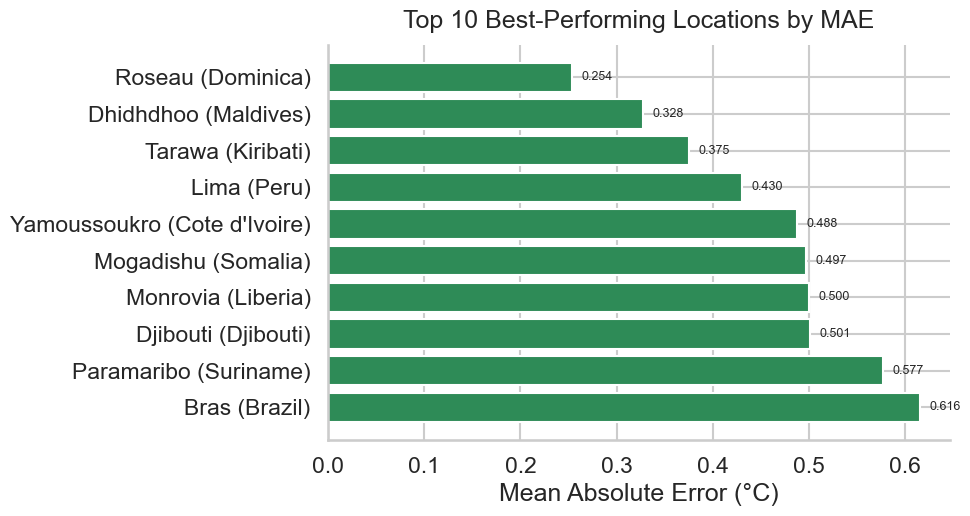

In [117]:
fig, ax = plt.subplots(figsize=(10, 5.5))
labels = top_best_locations["location_name"] + " (" + top_best_locations["country"] + ")"
bars = ax.barh(labels, top_best_locations["mae"], color="seagreen")

ax.set_title("Top 10 Best-Performing Locations by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

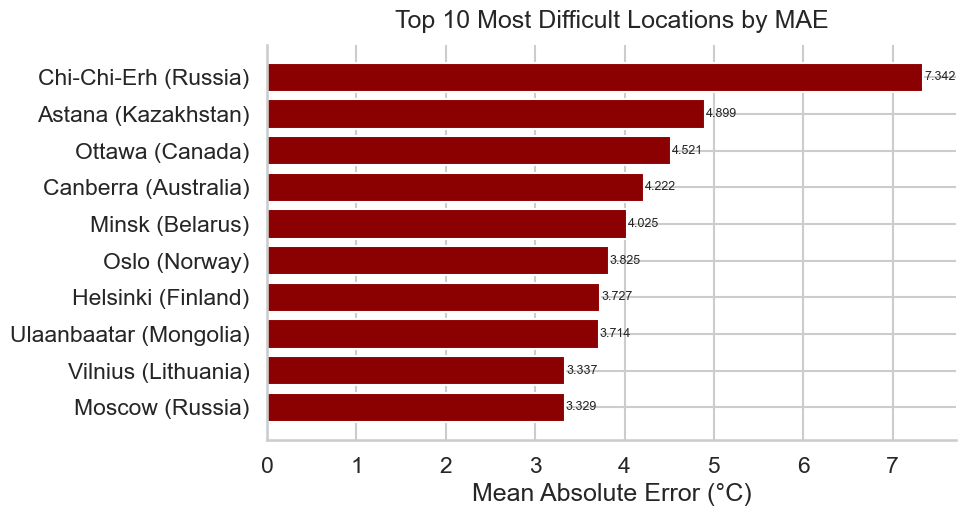

In [118]:
fig, ax = plt.subplots(figsize=(10, 5.5))
labels = top_worst_locations["location_name"] + " (" + top_worst_locations["country"] + ")"
bars = ax.barh(labels, top_worst_locations["mae"], color="darkred")

ax.set_title("Top 10 Most Difficult Locations by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

Forecasting quality is not uniform across locations.  
Some cities exhibit consistently low error, while others remain more difficult, which is expected in a global dataset combining different local climates, seasonal regimes, and short-term variability patterns.

## 10. Extreme errors and difficult cases

In [119]:
duplicate_keys = (
    feature_df.groupby(["location_name", "country", "last_updated"])
    .size()
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
)

duplicate_keys.head(20)

,location_name,country,last_updated,count
79852,Nan,Thailand,2026-02-20 14:00:00,2


In [120]:
duplicate_keys.shape

(1, 4)

### Auxiliary merge validation

A duplicate-key check showed only one repeated `(location_name, country, last_updated)` combination in the engineered feature dataset, associated with a missing location name.  
To keep the enrichment step consistent and preserve a one-to-one merge, duplicate lookup rows were removed before joining auxiliary variables for post-model error analysis.

In [121]:
feature_lookup = (
    feature_df[
        ["location_name", "country", "last_updated", "temperature_celsius", "latitude", "longitude"]
    ]
    .drop_duplicates(subset=["location_name", "country", "last_updated"])
    .copy()
)

best_preds = best_preds.merge(
    feature_lookup,
    on=["location_name", "country", "last_updated"],
    how="left",
    validate="many_to_one",
)

best_preds["temp_change"] = (
    best_preds["target_temperature_next"] - best_preds["temperature_celsius"]
)

best_preds[[
    "location_name",
    "last_updated",
    "temperature_celsius",
    "target_temperature_next",
    "temp_change",
    "absolute_error",
]].head()

,location_name,last_updated,temperature_celsius,target_temperature_next,temp_change,absolute_error
0,Madrid,2025-11-04 08:45:00,7.3,12.3,5.0,3.278873
1,Warsaw,2025-11-04 09:00:00,7.4,6.1,-1.3,1.948903
2,'S-Gravenbrakel,2025-11-04 09:00:00,12.1,12.3,0.2,1.646108
3,Andorra La Vella,2025-11-04 09:00:00,6.3,5.5,-0.8,1.291142
4,Amsterdam,2025-11-04 09:00:00,13.4,12.3,-1.1,1.125140


In [122]:
hard_cases = best_preds.sort_values("absolute_error", ascending=False).copy()

hard_case_columns = [
    "location_name",
    "country",
    "last_updated",
    "temperature_celsius",
    "target_temperature_next",
    "prediction",
    "error",
    "absolute_error",
    "temp_change",
]

hard_cases[hard_case_columns].head(15)

,location_name,country,last_updated,temperature_celsius,target_temperature_next,prediction,error,absolute_error,temp_change
9273,Chi-Chi-Erh,Russia,2025-12-21 14:00:00,-16.8,-14.0,8.134074,-22.134074,22.134074,2.8
9857,Chi-Chi-Erh,Russia,2025-12-24 14:00:00,-14.8,-18.8,0.640889,-19.440889,19.440889,-4.0
10041,Astana,Kazakhstan,2025-12-25 12:00:00,-3.6,-22.8,-3.629125,-19.170875,19.170875,-19.2
6724,Astana,Kazakhstan,2025-12-08 12:15:00,0.1,-18.9,0.254217,-19.154217,19.154217,-19.0
12525,Bogot,Bulgaria,2026-01-07 09:15:00,4.4,-14.6,4.482285,-19.082285,19.082285,-19.0
9664,Chi-Chi-Erh,Russia,2025-12-23 14:15:00,-14.0,-14.8,3.822559,-18.622559,18.622559,-0.8
5801,Ottawa,Canada,2025-12-04 02:00:00,-0.7,-21.0,-3.218307,-17.781693,17.781693,-20.3
21048,Oslo,Norway,2026-02-21 07:45:00,4.2,-13.9,3.767760,-17.667760,17.667760,-18.1
20357,Ashgabat,Turkmenistan,2026-02-17 11:45:00,6.2,24.2,7.707705,16.492295,16.492295,18.0
24003,Astana,Kazakhstan,2026-03-08 11:45:00,0.5,-15.9,0.017263,-15.917263,15.917263,-16.4


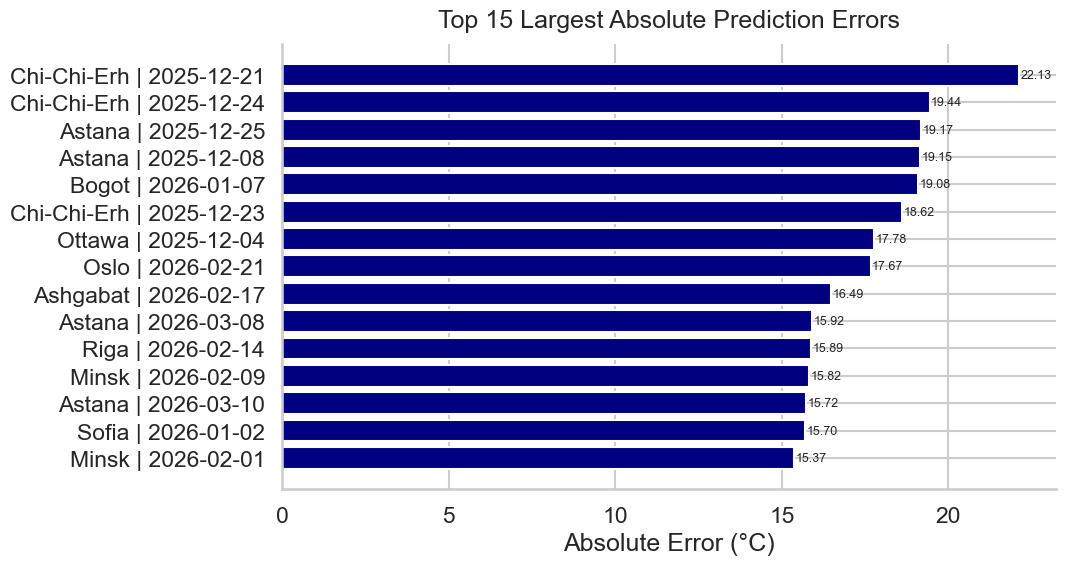

In [123]:
top_hard_cases = hard_cases.head(15).copy()
top_hard_cases["label"] = (
    top_hard_cases["location_name"]
    + " | "
    + top_hard_cases["last_updated"].astype(str).str[:10]
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_hard_cases["label"], top_hard_cases["absolute_error"], color="navy")

ax.set_title("Top 15 Largest Absolute Prediction Errors", pad=12)
ax.set_xlabel("Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height() / 2, f"{width:.2f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

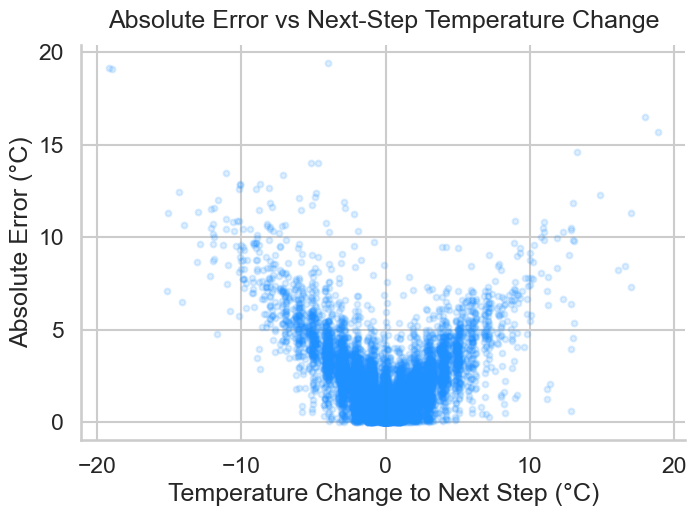

In [124]:
sample_n = min(len(best_preds), 12000)
change_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(change_sample["temp_change"], change_sample["absolute_error"], c="dodgerblue", alpha=0.15, s=18)

ax.set_title("Absolute Error vs Next-Step Temperature Change", pad=12)
ax.set_xlabel("Temperature Change to Next Step (°C)")
ax.set_ylabel("Absolute Error (°C)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

The largest errors tend to appear in more volatile transitions, where the next-step temperature changes more abruptly.  
This is consistent with the earlier finding that recent thermal history is the dominant predictive signal: the model is strongest when short-term continuity holds and weaker when the local trajectory changes sharply.

## 11. Geographic performance patterns

In [125]:
best_preds["latitude_band"] = pd.cut(
    best_preds["latitude"],
    bins=[-90, -60, -30, 0, 30, 60, 90],
    labels=["-90 to -60", "-60 to -30", "-30 to 0", "0 to 30", "30 to 60", "60 to 90"],
)

latitude_error_df = (
    best_preds.groupby("latitude_band", observed=False, as_index=False)
    .agg(
        n_predictions=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda s: np.sqrt(np.mean(np.square(s)))),
    )
)

latitude_error_df

,latitude_band,n_predictions,mae,rmse
0,-90 to -60,0,NaN,NaN
1,-60 to -30,666,2.384892,3.187932
2,-30 to 0,4947,1.239305,1.680714
3,0 to 30,10176,1.155449,1.633252
4,30 to 60,10012,2.538283,3.426593
5,60 to 90,266,3.169969,4.111431


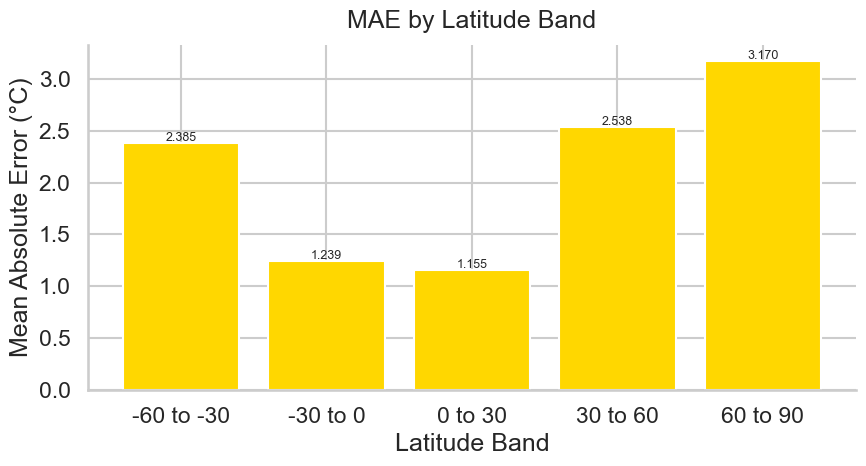

In [126]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(latitude_error_df["latitude_band"].astype(str), latitude_error_df["mae"], color="gold")

ax.set_title("MAE by Latitude Band", pad=12)
ax.set_xlabel("Latitude Band")
ax.set_ylabel("Mean Absolute Error (°C)")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}", ha="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

This view helps assess whether the model generalizes evenly across broad geographic contexts.  
Meaningful differences across latitude bands may indicate that some climate regimes are harder to represent with the current feature set and modeling strategy.

## 12. Final interpretation

In [127]:
final_text = f'''
### Final interpretation

The strongest baseline was **{best_baseline["model"]}**, confirming that short-term temperature forecasting in this dataset has strong temporal persistence.  
Even so, the final tuned **Random Forest** model improved on that baseline and achieved the best overall performance with **MAE = {best_tuned_rf["mae"]:.3f}**, **RMSE = {best_tuned_rf["rmse"]:.3f}**, and **R² = {best_tuned_rf["r2"]:.3f}**.

Across the predefined Random Forest feature blocks, the best untuned configuration was **{best_untuned_rf["feature_set"]}**, indicating that **temporal + meteorological + geographic** information offered the best balance between predictive signal and model complexity.  
The full feature block, including air-quality variables, did not outperform this intermediate setup within the Random Forest family, suggesting that a larger feature set was not automatically better for this target.

A second ensemble family, **HistGradientBoostingRegressor**, was evaluated under the same temporal holdout and time-aware tuning protocol.  
Although it remained competitive, the tuned HGB model did **not** outperform the tuned Random Forest. This reinforced the final model choice and made the selection process more defensible.

Permutation importance showed that the dominant predictors were **current temperature**, **feels-like temperature**, **rolling temperature averages**, and **lagged temperatures**.  
This reinforces the conclusion that short-term thermal history is the main driver of predictive performance, while geographic and broader meteorological variables add incremental value.

The location-level and extreme-error analyses showed that model quality is not uniform across the globe and that the largest errors are associated with more abrupt temperature transitions.  
This means the pipeline is effective for short-term forecasting under stable local dynamics, but remains less reliable in more volatile situations.

Overall, the project demonstrates that a structured forecasting workflow — including data audit, feature engineering, strong baseline comparison, block-wise modeling, time-aware hyperparameter tuning, cross-family model benchmarking, and post-hoc error analysis — can produce reliable global short-term weather forecasts from daily observational data.
'''
display(Markdown(final_text))


### Final interpretation

The strongest baseline was **last_observation**, which confirms that short-term temperature forecasting in this dataset has strong temporal persistence.  
Even so, the final tuned Random Forest model improved on that baseline and achieved the best overall performance with **MAE = 1.744**, **RMSE = 2.529**, and **R² = 0.949**.

Across the predefined feature blocks, the best untuned configuration was **C_temporal_meteorology_geography**, indicating that **temporal + meteorological + geographic** information offered the best balance between predictive signal and model complexity.  
The full feature block, including air-quality variables, did not outperform this intermediate setup, suggesting that a larger feature set was not automatically better for this target.

Permutation importance showed that the dominant predictors were **current temperature**, **feels-like temperature**, **rolling temperature averages**, and **lagged temperatures**.  
This reinforces the 